In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# import nessecory lib.

In [ ]:
# loding the dataset 
train = pd.read_csv('../data/raw/train.csv')
test = pd.read_csv('../data/raw/test.csv')
fulfilment = pd.read_csv('../data/raw/fulfilment_center_info.csv')
meal = pd.read_csv('../data/raw/meal_info.csv')

In [3]:
train_merged = train.merge(fulfilment, on = 'center_id', how = 'left')  # merge the dataset train and fulfilment 
train_merged = train_merged.merge(meal, on = 'meal_id', how = 'left')   # merge the dataset train_merged and meal

test_merged = test.merge(fulfilment, on = 'center_id', how = 'left')    # same as training data merge test data
test_merged = test_merged.merge(meal, on = 'meal_id', how = 'left')

In [ ]:
train_merged.to_csv('../data/processed/train_merged.csv', index = False)  # save the copy of merged datdasets
test_merged.to_csv('../data/processed/test_merged.csv', index = False)

In [5]:
print(train_merged.isna().sum())        # check the null values
print(f'\nduplicated values : {train_merged.duplicated().sum()}')       # check the duplicated values

id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
city_code                0
region_code              0
center_type              0
op_area                  0
category                 0
cuisine                  0
dtype: int64

duplicated values : 0


In [6]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian


In [7]:
wk = train_merged.groupby("week", as_index=False)["num_orders"].sum()
# no. of total orders per week 

In [8]:
wk

,week,num_orders
0,1,792261
1,2,787084
2,3,695262
3,4,743529
4,5,1198675
...,...,...
140,141,776240
141,142,739661
142,143,759926
143,144,801197


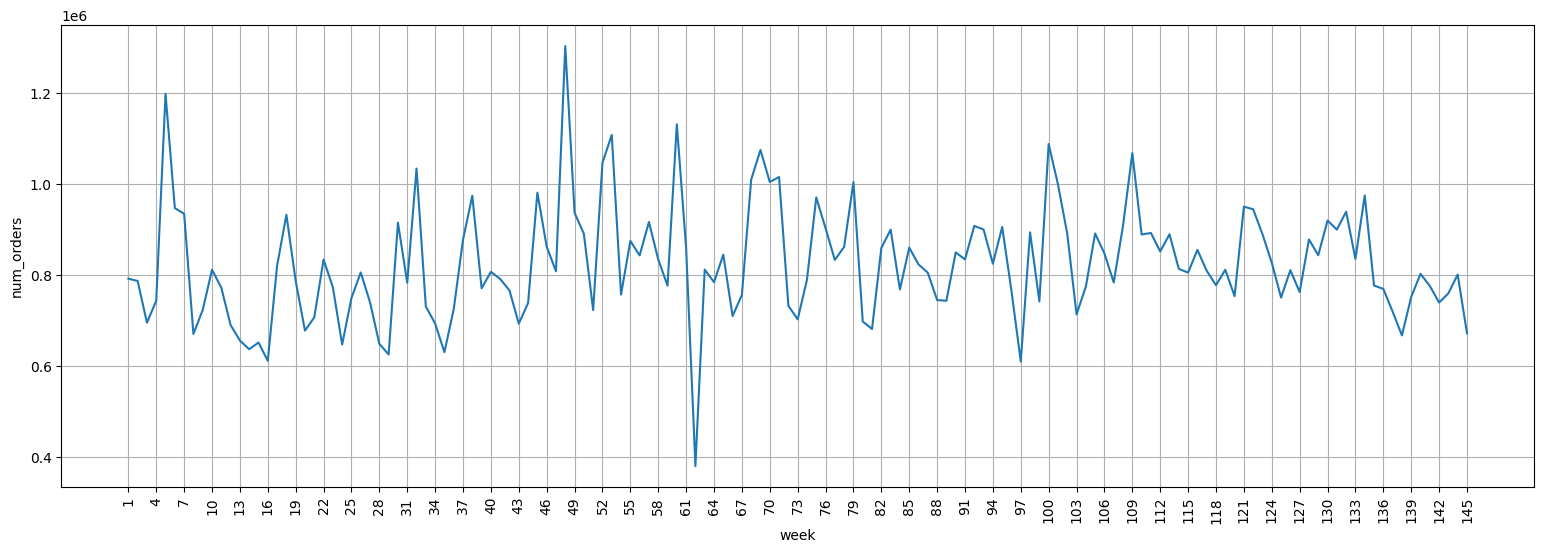

In [9]:
plt.figure(figsize=(19, 6))
sns.lineplot(wk, y = 'num_orders', x = 'week', markers = 'o')
plt.xticks(wk['week'][::3], rotation = 90)
plt.grid()
plt.show()

In [10]:
train_merged['discount'] = train_merged['base_price'] - train_merged['checkout_price']
# cal the discount 

In [11]:
train_merged['discount'] = train_merged['discount'].round(2)

In [12]:
train_merged.sort_values(by ='discount' ,ascending=False)

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount
108288,1419554,37,102,2444,145.53,707.13,0,0,54,593,77,TYPE_A,2.8,Seafood,Continental,561.60
287522,1176573,94,92,2444,163.93,708.13,1,0,15,526,34,TYPE_C,2.9,Seafood,Continental,544.20
258834,1000988,85,161,2304,226.04,736.23,0,0,69,658,34,TYPE_B,3.9,Desert,Indian,510.19
111288,1192242,38,102,2444,243.50,708.13,0,0,15,593,77,TYPE_A,2.8,Seafood,Continental,464.63
262090,1181537,86,161,2304,338.59,736.23,1,1,134,658,34,TYPE_B,3.9,Desert,Indian,397.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
331761,1332869,107,23,1230,497.61,325.01,0,1,42,698,23,TYPE_A,3.4,Beverages,Continental,-172.60
327056,1290542,106,153,2322,496.64,322.10,0,1,41,590,56,TYPE_A,3.9,Beverages,Continental,-174.54
331762,1056437,107,23,2322,503.49,324.01,0,1,13,698,23,TYPE_A,3.4,Beverages,Continental,-179.48
328498,1238282,106,23,2322,508.31,324.01,0,1,121,698,23,TYPE_A,3.4,Beverages,Continental,-184.30


In [13]:
train_merged["discount_per"] = (((train_merged["base_price"] - train_merged["checkout_price"])/ train_merged["base_price"]) * 100).round(2)
# cal the discount per for the each id

In [14]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,15.46,10.15
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,-1.00,-0.74
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,1.00,0.74
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,98.03,22.41
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,-1.00,-0.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian,83.39,25.97
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian,69.84,22.29


In [15]:
train_merged.sort_values(by ='discount_per' ,ascending=False)

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per
110286,1300283,38,73,1230,2.97,316.25,0,0,14,576,34,TYPE_A,4.0,Beverages,Continental,313.28,99.06
173526,1017697,58,102,1109,56.26,319.13,0,0,229,593,77,TYPE_A,2.8,Rice Bowl,Indian,262.87,82.37
44875,1381921,16,41,1248,45.62,253.23,0,0,123,590,56,TYPE_C,1.9,Beverages,Indian,207.61,81.98
44874,1414392,16,41,2631,47.59,253.23,0,0,163,590,56,TYPE_C,1.9,Beverages,Indian,205.64,81.21
224346,1472105,74,80,1198,65.02,319.13,0,0,69,604,56,TYPE_C,5.1,Extras,Thai,254.11,79.63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328497,1406829,106,23,1230,509.31,324.01,0,1,107,698,23,TYPE_A,3.4,Beverages,Continental,-185.30,-57.19
442314,1267391,141,72,1248,163.93,98.03,0,1,27,638,56,TYPE_C,3.9,Beverages,Indian,-65.90,-67.22
442313,1288740,141,72,2631,163.93,98.03,0,1,69,638,56,TYPE_C,3.9,Beverages,Indian,-65.90,-67.22
445564,1228305,142,72,1248,163.02,97.03,0,1,80,638,56,TYPE_C,3.9,Beverages,Indian,-65.99,-68.01


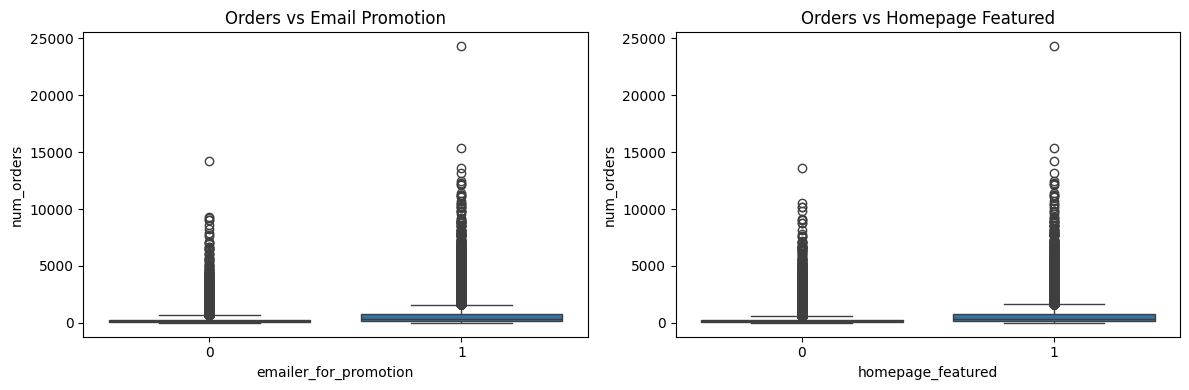

In [16]:

fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.boxplot(data=train_merged, x="emailer_for_promotion", y="num_orders", ax=ax[0])
ax[0].set_title("Orders vs Email Promotion")

sns.boxplot(data=train_merged, x="homepage_featured", y="num_orders", ax=ax[1])
ax[1].set_title("Orders vs Homepage Featured")
plt.tight_layout()
plt.show()


# is affect of orders on promotion via plot

In [17]:
train_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     456548 non-null  int64  
 1   week                   456548 non-null  int64  
 2   center_id              456548 non-null  int64  
 3   meal_id                456548 non-null  int64  
 4   checkout_price         456548 non-null  float64
 5   base_price             456548 non-null  float64
 6   emailer_for_promotion  456548 non-null  int64  
 7   homepage_featured      456548 non-null  int64  
 8   num_orders             456548 non-null  int64  
 9   city_code              456548 non-null  int64  
 10  region_code            456548 non-null  int64  
 11  center_type            456548 non-null  object 
 12  op_area                456548 non-null  float64
 13  category               456548 non-null  object 
 14  cuisine                456548 non-nu

In [18]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,15.46,10.15
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,-1.00,-0.74
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,1.00,0.74
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,98.03,22.41
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,-1.00,-0.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian,83.39,25.97
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian,69.84,22.29


<Axes: >

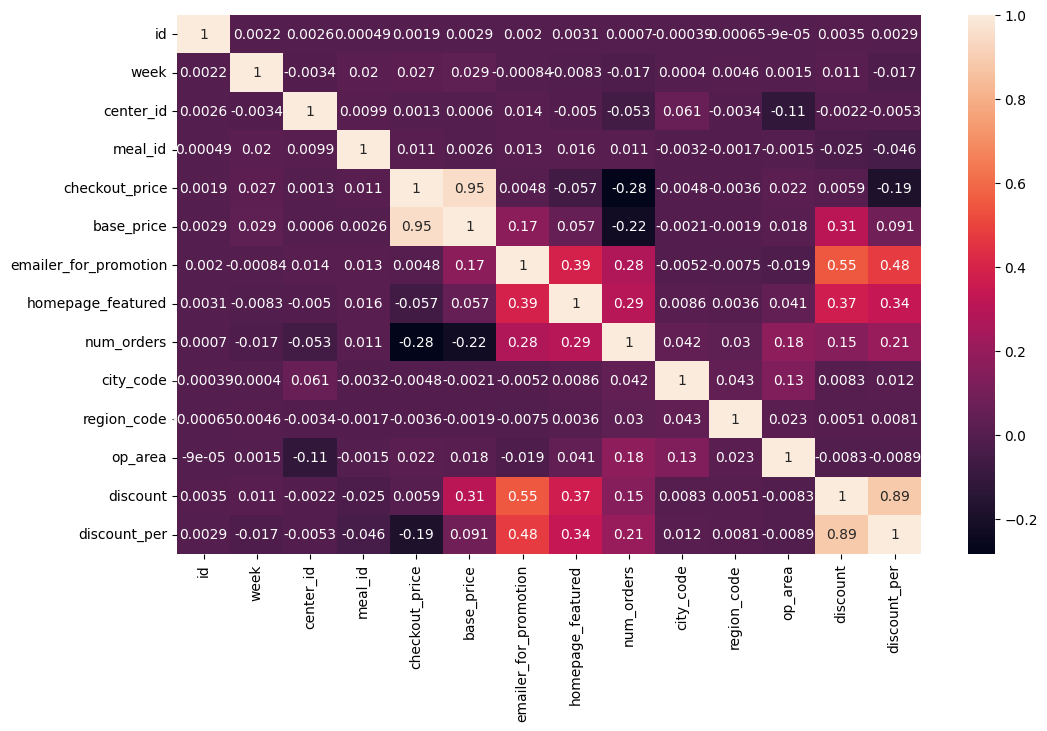

In [19]:
plt.figure(figsize=(12,7))
sns.heatmap(train_merged.corr(numeric_only=True), annot=True)
# correlataion

In [20]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,15.46,10.15
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,-1.00,-0.74
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,1.00,0.74
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,98.03,22.41
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,-1.00,-0.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian,83.39,25.97
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian,69.84,22.29


In [21]:
total_order_center = train_merged.groupby('center_id')['num_orders'].sum()
# total order delivered by each center

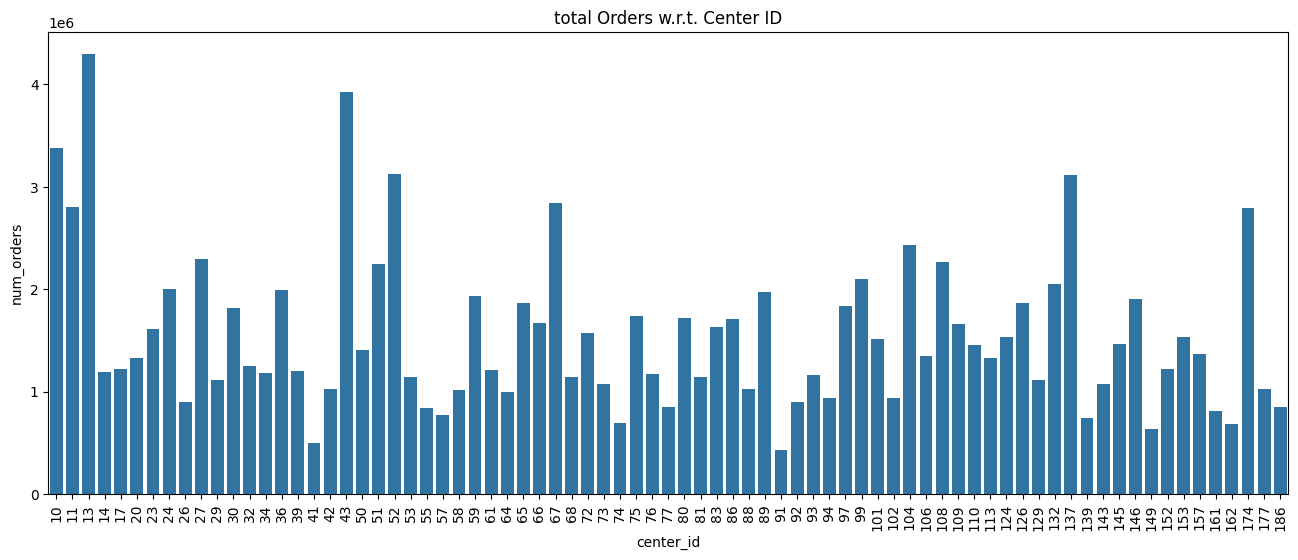

In [22]:
plt.figure(figsize = (16,6))
sns.barplot(total_order_center)
plt.xticks(rotation = 90)
plt.title('total Orders w.r.t. Center ID')
plt.show()

In [23]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,15.46,10.15
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,-1.00,-0.74
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,1.00,0.74
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,98.03,22.41
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,-1.00,-0.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian,83.39,25.97
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian,69.84,22.29


In [24]:
train_merged['center_type'].value_counts()

center_type
TYPE_A    262881
TYPE_C     99593
TYPE_B     94074
Name: count, dtype: int64

<Axes: xlabel='center_type', ylabel='num_orders'>

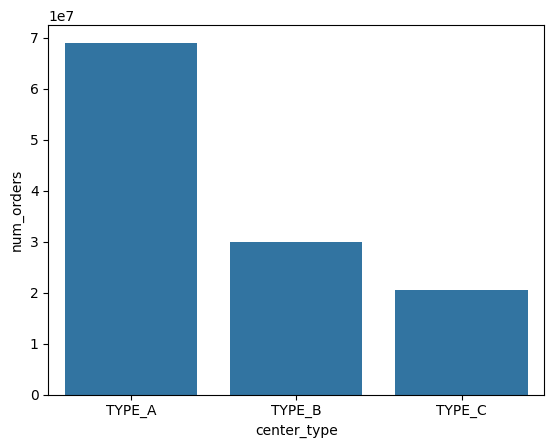

In [25]:
total_order_center_type = train_merged.groupby('center_type')['num_orders'].sum()
sns.barplot(total_order_center_type)

In [26]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,15.46,10.15
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,-1.00,-0.74
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,1.00,0.74
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,98.03,22.41
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,-1.00,-0.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian,83.39,25.97
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian,69.84,22.29


<Axes: xlabel='region_code', ylabel='num_orders'>

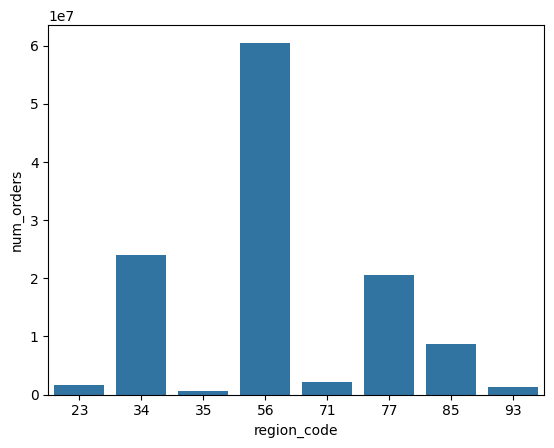

In [27]:
total_order_region = train_merged.groupby('region_code')['num_orders'].sum()

sns.barplot(total_order_region)
# no of orders in each region

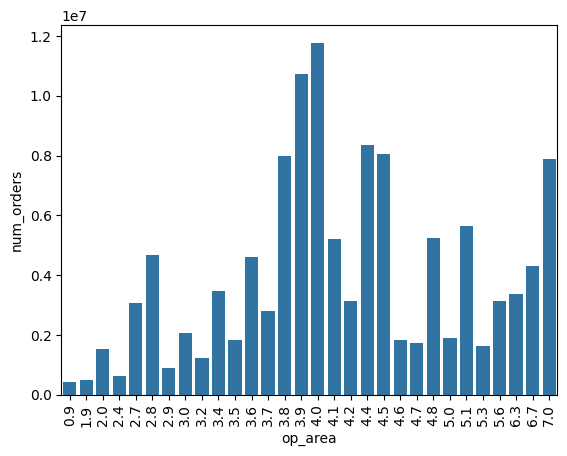

In [28]:
total_order_area = train_merged.groupby('op_area')['num_orders'].sum()

sns.barplot(total_order_area)
plt.xticks(rotation = 90)
plt.show()

# total orders acc to oprationl area

In [29]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,15.46,10.15
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,-1.00,-0.74
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,1.00,0.74
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,98.03,22.41
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,-1.00,-0.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian,83.39,25.97
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian,69.84,22.29


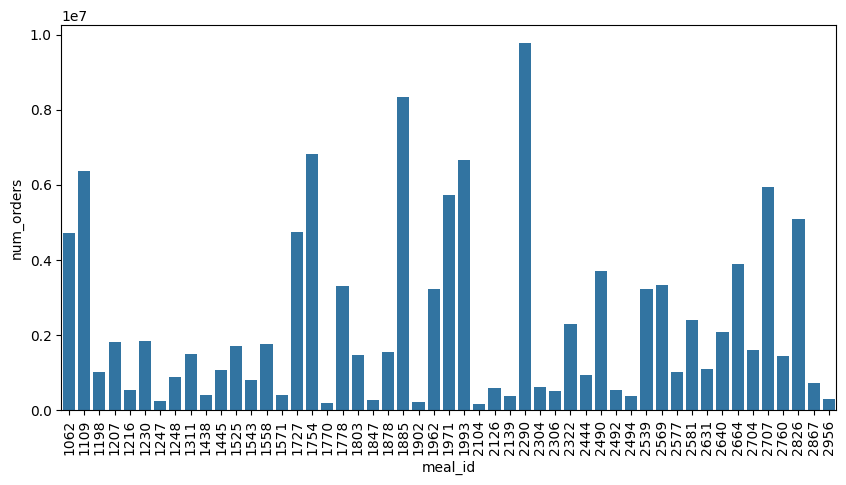

In [30]:
total_order_meal = train_merged.groupby('meal_id')['num_orders'].sum()
plt.figure(figsize=(10,5))
sns.barplot(total_order_meal)
plt.xticks(rotation = 90)
plt.show()

# order as per meal 

In [31]:
print(train_merged['cuisine'].value_counts())
print(train_merged['category'].value_counts())

cuisine
Italian        122925
Thai           118216
Indian         112612
Continental    102795
Name: count, dtype: int64
category
Beverages       127890
Rice Bowl        33408
Sandwich         33291
Pizza            33138
Starters         29941
Other Snacks     29379
Desert           29294
Salad            28559
Pasta            27694
Seafood          26916
Biryani          20614
Extras           13562
Soup             12675
Fish             10187
Name: count, dtype: int64


In [32]:


meal_week = (
    train_merged.groupby(["meal_id", "week"], as_index=False)["num_orders"]
    .sum()
    .sort_values(["meal_id", "week"])
)

# seasonal strength score per meal (higher = stronger repeating pattern)
seasonality = (
    meal_week.groupby("meal_id")["num_orders"]
    .apply(lambda s: s.autocorr(lag=52) if len(s) > 52 else np.nan)
    .reset_index(name="seasonality_score")
    .sort_values("seasonality_score", ascending=False)
)

seasonality.head(20)   # strongest seasonal meals


,meal_id,seasonality_score
20,1847,0.753204
32,2306,0.600986
37,2494,0.580460
9,1438,0.550967
19,1803,0.471212
36,2492,0.466017
15,1727,0.429894
22,1885,0.405325
26,1993,0.405049
5,1230,0.393160


In [33]:
train_merged.loc[train_merged["discount_per"] < 0, "discount_per"] = 0

In [34]:
disc_bins = [-0.01, 0, 5, 10, 20, 30, 40, 50, 100]
disc_labels = ["0%", "0-5%", "5-10%", "10-20%", "20-30%", "30-40%", "40-50%", "50%+"]

train_merged["discount_bin"] = pd.cut(
    train_merged["discount_per"],
    bins=disc_bins,
    labels=disc_labels,
    include_lowest=True
)

# Demand vs discount bins
disc_summary = (
    train_merged.groupby("discount_bin", observed=False)["num_orders"]
    .agg(total_orders="sum", avg_orders="mean", count="count")
    .reset_index()
)
disc_summary

,discount_bin,total_orders,avg_orders,count
0,0%,49307770,217.346019,226863
1,0-5%,25265319,219.728997,114984
2,5-10%,1732646,372.932845,4646
3,10-20%,18021618,346.256614,52047
4,20-30%,10542801,353.963438,29785
5,30-40%,9625242,443.600424,21698
6,40-50%,4585552,1059.753178,4327
7,50%+,476537,216.804823,2198


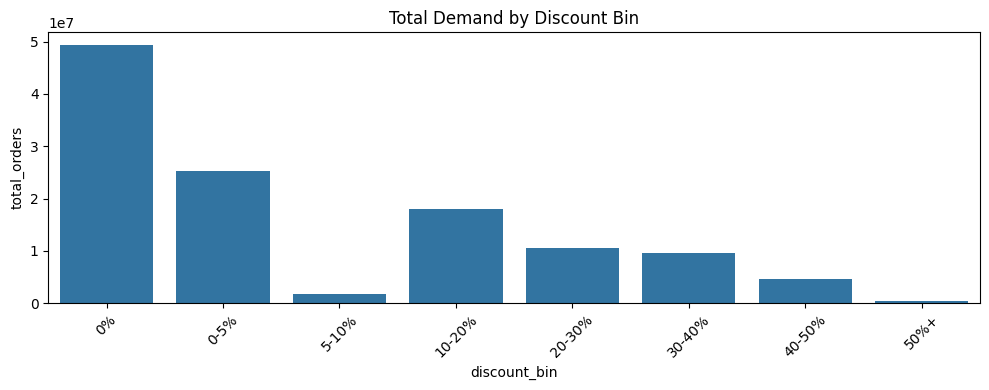

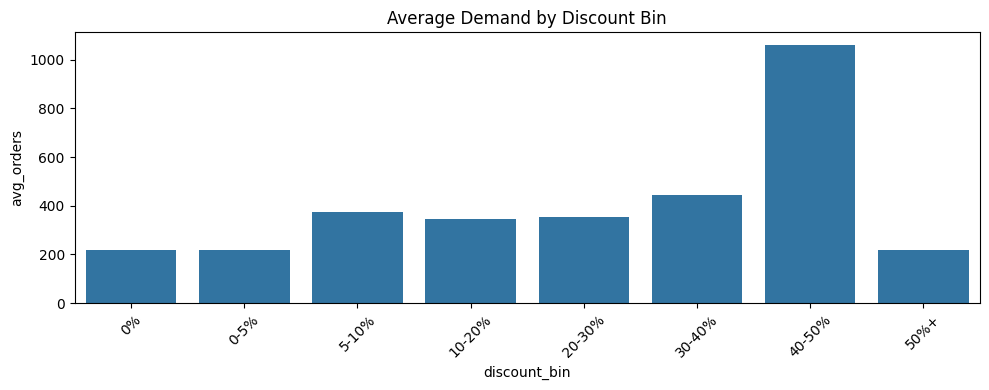

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
sns.barplot(data=disc_summary, x="discount_bin", y="total_orders")
plt.title("Total Demand by Discount Bin")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
sns.barplot(data=disc_summary, x="discount_bin", y="avg_orders")
plt.title("Average Demand by Discount Bin")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [36]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per,discount_bin
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,15.46,10.15,10-20%
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,-1.00,0.00,0%
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,1.00,0.74,0-5%
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,98.03,22.41,20-30%
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,-1.00,0.00,0%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00,0%
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00,0%
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian,83.39,25.97,20-30%
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian,69.84,22.29,20-30%


In [37]:
price_bins = [0, 100, 150, 200, 250, 300, 400, 600, np.inf]
price_labels = ["<=100", "101-150", "151-200", "201-250", "251-300", "301-400", "401-600", "600+"]

train_merged["price_band"] = pd.cut(
    train_merged["checkout_price"],
    bins=price_bins,
    labels=price_labels,
    include_lowest=True
)

price_summary = (
    train_merged.groupby("price_band", observed=False)["num_orders"]
    .agg(total_orders="sum", avg_orders="mean", count="count")
    .reset_index()
)
price_summary


,price_band,total_orders,avg_orders,count
0,<=100,3460572,293.592263,11787
1,101-150,15133121,506.531028,29876
2,151-200,25846781,419.542925,61607
3,201-250,16968062,339.762159,49941
4,251-300,21885341,279.806446,78216
5,301-400,19633391,223.187875,87968
6,401-600,13300279,136.004407,97793
7,600+,3329938,84.602083,39360


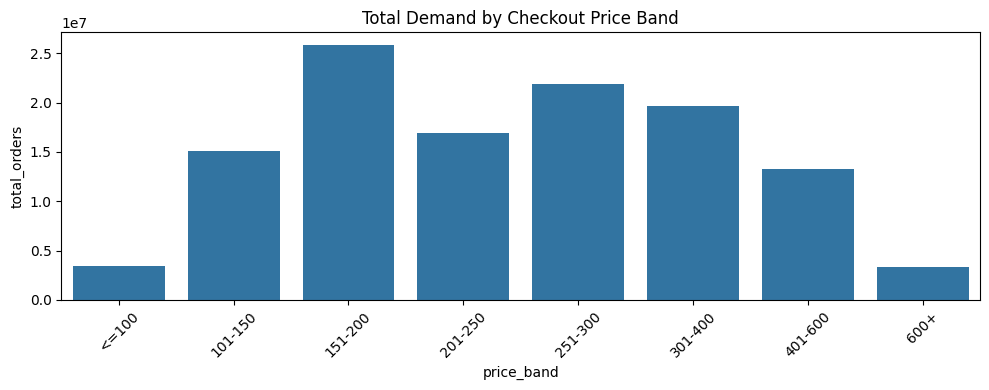

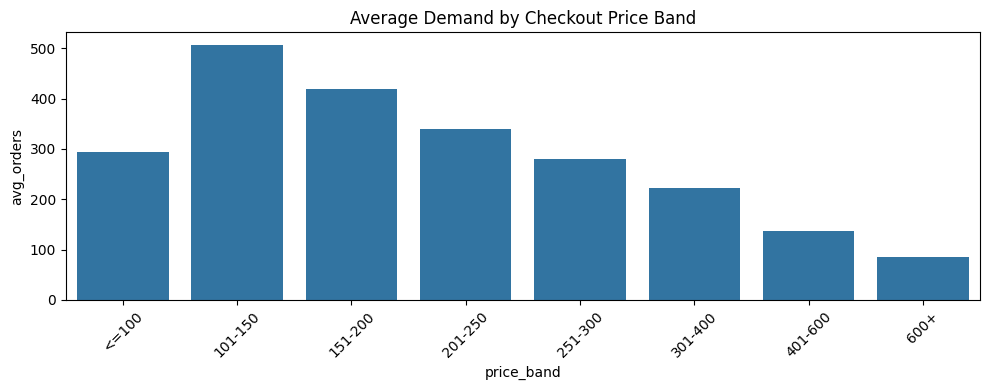

In [38]:
plt.figure(figsize=(10,4))
sns.barplot(data=price_summary, x="price_band", y="total_orders")
plt.title("Total Demand by Checkout Price Band")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
sns.barplot(data=price_summary, x="price_band", y="avg_orders")
plt.title("Average Demand by Checkout Price Band")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [39]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per,discount_bin,price_band
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,15.46,10.15,10-20%,101-150
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,-1.00,0.00,0%,101-150
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,1.00,0.74,0-5%,101-150
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,98.03,22.41,20-30%,301-400
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,-1.00,0.00,0%,201-250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00,0%,401-600
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00,0%,401-600
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian,83.39,25.97,20-30%,201-250
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian,69.84,22.29,20-30%,201-250


In [40]:
start_data = pd.Timestamp('2018-01-01')

train_merged['week_date'] = start_data + pd.to_timedelta((train_merged['week'] - 1) * 7, unit = 'D')

In [41]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per,discount_bin,price_band,week_date
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,15.46,10.15,10-20%,101-150,2018-01-01
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,-1.00,0.00,0%,101-150,2018-01-01
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,1.00,0.74,0-5%,101-150,2018-01-01
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,98.03,22.41,20-30%,301-400,2018-01-01
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,-1.00,0.00,0%,201-250,2018-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00,0%,401-600,2020-10-05
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00,0%,401-600,2020-10-05
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian,83.39,25.97,20-30%,201-250,2020-10-05
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian,69.84,22.29,20-30%,201-250,2020-10-05


In [42]:
test_merged['week_date'] = start_data + pd.to_timedelta((test_merged['week'] - 1) * 7, unit = 'D')

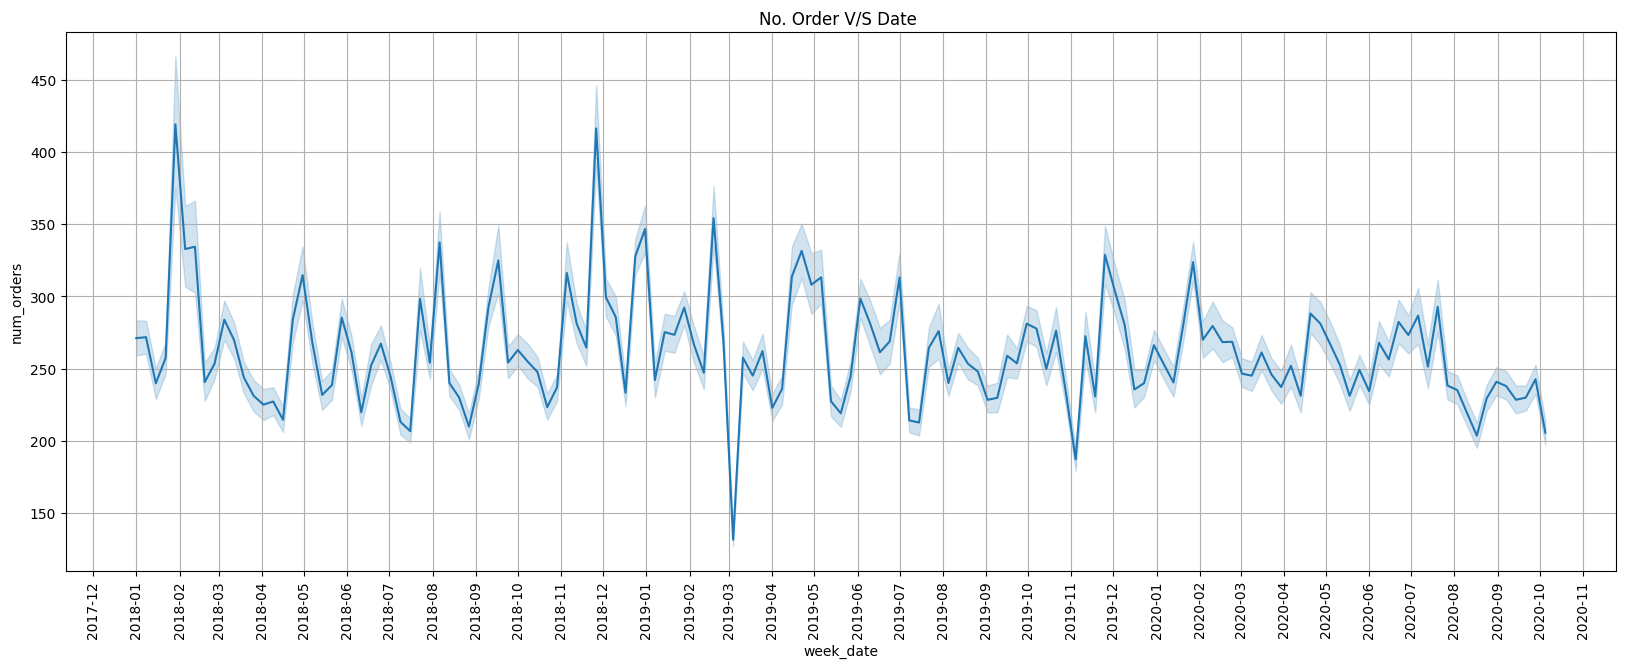

In [43]:
import matplotlib.dates as mdates
plt.figure(figsize=(20,7))
sns.lineplot(train_merged, x = 'week_date', y = 'num_orders')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation = 90)
plt.title('No. Order V/S Date ')
plt.grid()
plt.show()

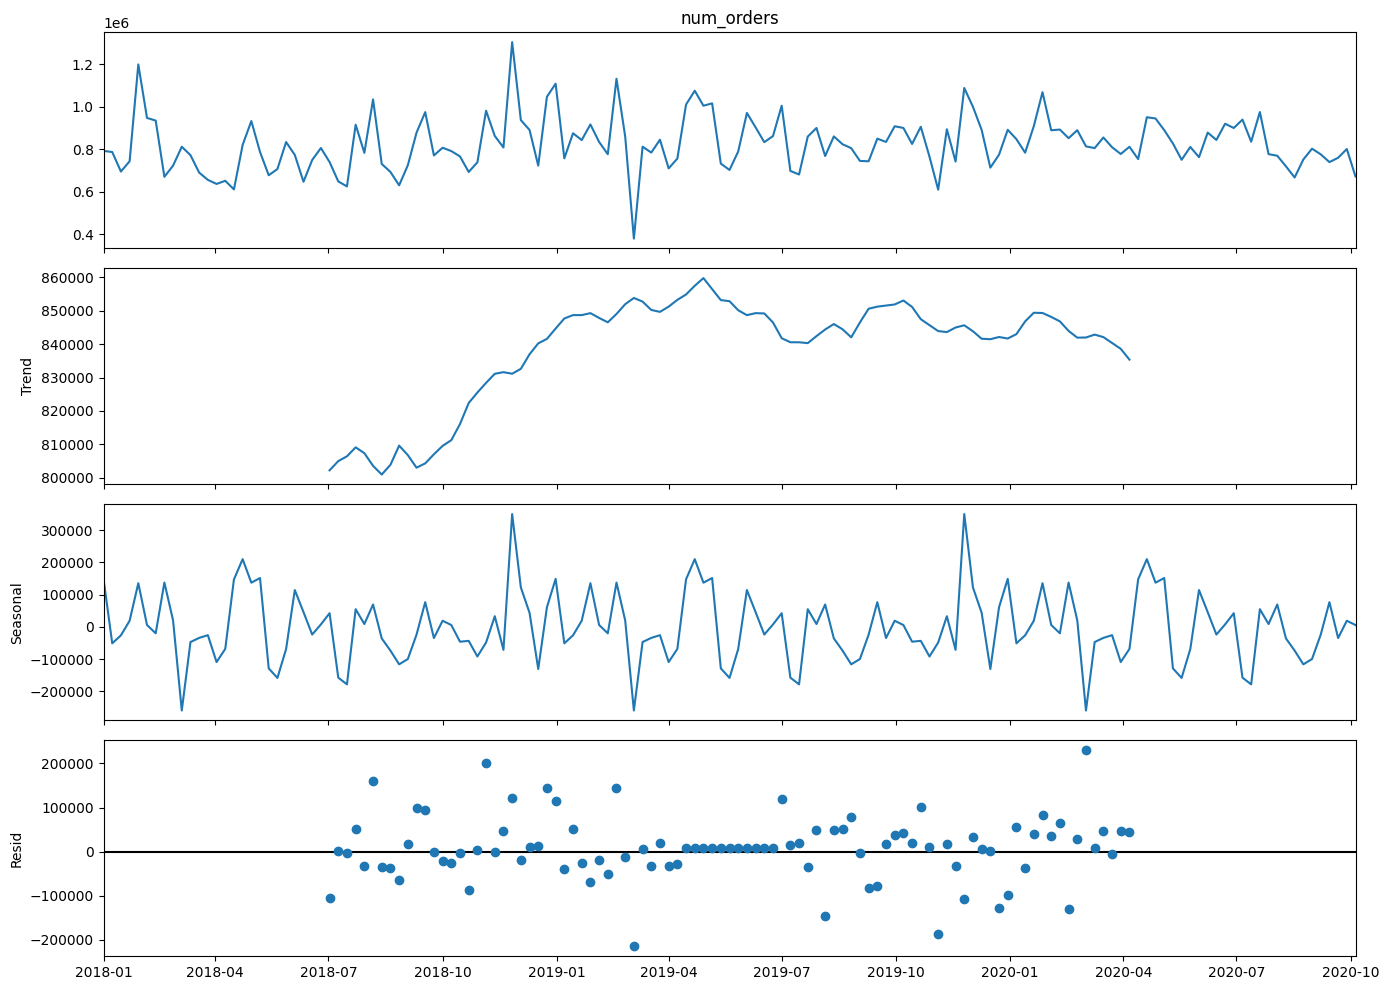

In [44]:
from statsmodels.tsa.seasonal import seasonal_decompose

ts = train_merged.groupby('week_date')['num_orders'].sum().sort_index()

result = seasonal_decompose(ts, ) # model = 'additive', period = 52
fit = result.plot()
fit.set_size_inches(14, 10)
plt.tight_layout()
plt.show()

In [45]:
ts

week_date
2018-01-01     792261
2018-01-08     787084
2018-01-15     695262
2018-01-22     743529
2018-01-29    1198675
               ...   
2020-09-07     776240
2020-09-14     739661
2020-09-21     759926
2020-09-28     801197
2020-10-05     671926
Name: num_orders, Length: 145, dtype: int64

In [46]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


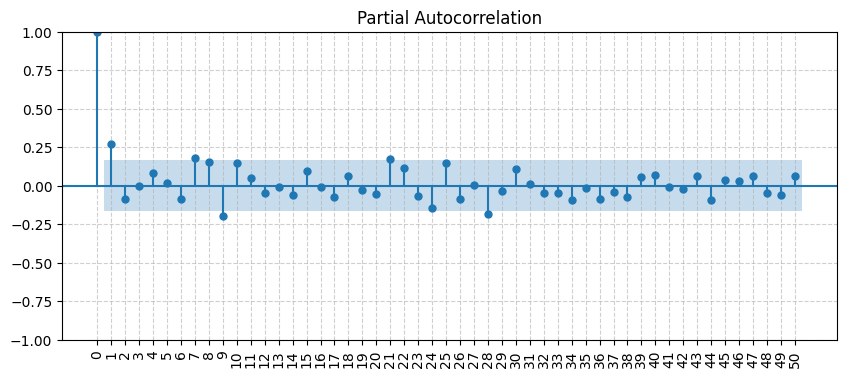

In [47]:
fig, ax = plt.subplots(figsize=(10,4))
plot_pacf(ts, lags=50, method="ywm", ax=ax)

ax.set_xticks(range(0, 51))   # one tick per lag
ax.grid(True, which="major", axis="both", linestyle="--", alpha=0.6)
plt.xticks(rotation = 90)
plt.show()
# corr with past orders

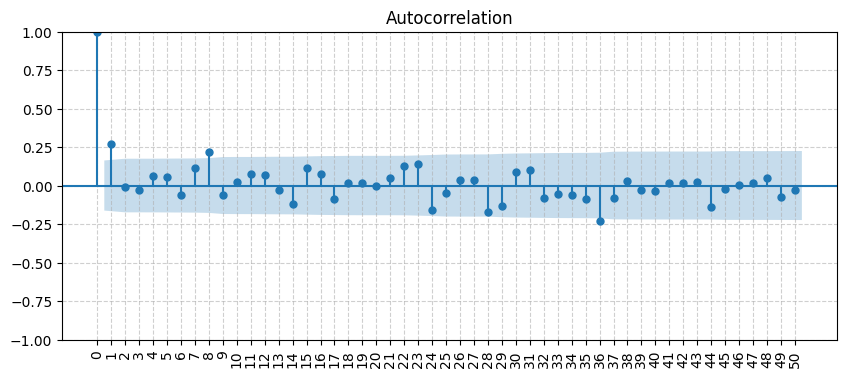

In [48]:
fig, ax = plt.subplots(figsize=(10,4))
plot_acf(ts, lags=50, ax=ax)

ax.set_xticks(range(0, 51))   # one tick per lag
ax.grid(True, which="major", axis="both", linestyle="--", alpha=0.6)
plt.xticks(rotation = 90)
plt.show()

In [49]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per,discount_bin,price_band,week_date
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,15.46,10.15,10-20%,101-150,2018-01-01
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,-1.00,0.00,0%,101-150,2018-01-01
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,1.00,0.74,0-5%,101-150,2018-01-01
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,98.03,22.41,20-30%,301-400,2018-01-01
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,-1.00,0.00,0%,201-250,2018-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00,0%,401-600,2020-10-05
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00,0%,401-600,2020-10-05
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian,83.39,25.97,20-30%,201-250,2020-10-05
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian,69.84,22.29,20-30%,201-250,2020-10-05


In [50]:
train_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   id                     456548 non-null  int64         
 1   week                   456548 non-null  int64         
 2   center_id              456548 non-null  int64         
 3   meal_id                456548 non-null  int64         
 4   checkout_price         456548 non-null  float64       
 5   base_price             456548 non-null  float64       
 6   emailer_for_promotion  456548 non-null  int64         
 7   homepage_featured      456548 non-null  int64         
 8   num_orders             456548 non-null  int64         
 9   city_code              456548 non-null  int64         
 10  region_code            456548 non-null  int64         
 11  center_type            456548 non-null  object        
 12  op_area                456548 non-null  floa

In [51]:
train_merged['id'].name

'id'

In [52]:
for i in train_merged.columns:
    if train_merged[i].dtype not in ['int64' , 'float64']:
        print(f'{train_merged[i].name} : {train_merged[i].nunique()}')

center_type : 3
category : 14
cuisine : 4
discount_bin : 8
price_band : 8
week_date : 145


In [53]:
cat_col = ['center_type', 'category', 'cuisine', 'discount_bin', 'price_band']

In [54]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False,               # for readable
                        handle_unknown='ignore'     # dont crash for unknown data
                        )

In [55]:
import joblib

joblib.dump(encoder, 'encoder.pkl')

['encoder.pkl']

In [56]:
encoder.fit(train_merged[cat_col])

encoded = encoder.transform(train_merged[cat_col])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cat_col))

In [57]:
encoded_df

,center_type_TYPE_A,center_type_TYPE_B,center_type_TYPE_C,category_Beverages,category_Biryani,category_Desert,category_Extras,category_Fish,category_Other Snacks,category_Pasta,...,discount_bin_5-10%,discount_bin_50%+,price_band_101-150,price_band_151-200,price_band_201-250,price_band_251-300,price_band_301-400,price_band_401-600,price_band_600+,price_band_<=100
0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
456544,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
456545,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
456546,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [58]:
encoded_df.index = train_merged.index

In [59]:
train_merged = pd.concat([train_merged.drop(columns=(cat_col)), encoded_df],axis=1)

In [60]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,...,discount_bin_5-10%,discount_bin_50%+,price_band_101-150,price_band_151-200,price_band_201-250,price_band_251-300,price_band_301-400,price_band_401-600,price_band_600+,price_band_<=100
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [61]:
print(train_merged.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 52 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   id                     456548 non-null  int64         
 1   week                   456548 non-null  int64         
 2   center_id              456548 non-null  int64         
 3   meal_id                456548 non-null  int64         
 4   checkout_price         456548 non-null  float64       
 5   base_price             456548 non-null  float64       
 6   emailer_for_promotion  456548 non-null  int64         
 7   homepage_featured      456548 non-null  int64         
 8   num_orders             456548 non-null  int64         
 9   city_code              456548 non-null  int64         
 10  region_code            456548 non-null  int64         
 11  op_area                456548 non-null  float64       
 12  discount               456548 non-null  floa

In [62]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,...,discount_bin_5-10%,discount_bin_50%+,price_band_101-150,price_band_151-200,price_band_201-250,price_band_251-300,price_band_301-400,price_band_401-600,price_band_600+,price_band_<=100
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [63]:
# for best prediction we pick only one store 

print(train_merged['center_id'].value_counts().head(),'\n')

center_id
13    7046
10    7015
52    6993
43    6970
67    6915
Name: count, dtype: int64 



In [64]:
# center id = 13 have the highest row count

In [65]:
center_id_13 = train_merged[train_merged['center_id'] == 13]
center_id_13

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,...,discount_bin_5-10%,discount_bin_50%+,price_band_101-150,price_band_151-200,price_band_201-250,price_band_251-300,price_band_301-400,price_band_401-600,price_band_600+,price_band_<=100
194,1171094,1,13,1885,135.86,122.28,0,1,2132,590,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
195,1068455,1,13,1993,134.86,122.28,0,1,2418,590,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
196,1105491,1,13,2539,133.86,133.86,0,0,474,590,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
197,1486384,1,13,2139,337.62,437.53,0,0,123,590,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
198,1345938,1,13,2631,252.23,437.47,0,0,162,590,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
453541,1385493,145,13,1543,484.03,485.03,0,0,270,590,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
453542,1076678,145,13,2304,486.03,485.03,0,0,149,590,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
453543,1012260,145,13,2664,241.59,335.62,0,0,770,590,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
453544,1268089,145,13,2569,241.53,337.56,0,0,798,590,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
